This notebook covers:
* Probable flight path inference using Gaussian process variational inference
* Loading and processing data from bumBLEbee tracking system
* Infering angles from bumBLEbee tracking system
* Making prediction of flight path using VI from inferred angles

In [140]:

import numpy as np
import matplotlib
matplotlib.rcParams["axes.formatter.limits"] = (-99, 99)
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import scipy.stats as sci
import pyproj
import math

timeOffset = 7000000 + 131464

# Loading & Processing Receiever Data


Load file helper function:

In [141]:
def LoadFile(fileName):
  with open(fileName, 'r') as f:
    filedata = f.read()
    return filedata

RFProfileFilePath = "../bluetooth_experiments/4TransmitterTrialResults/bluetooth_experiments-main-5/no rf amp experiments/noamploc2long.log"
packetsFilePath = "../bluetooth_experiments/bee_triangulation_test/bee4.txt"
GPSFile = "complexpath8/2025-03-26_12_09_13_my_iOS_device.csv"

Functions to load in a file from either a .pcap file (off a tag) or a .log file (produced by active_scanner.c running on a DA14531 dev board):

In [142]:
# Split data from dev board active_scanner.c into packets
def ParseDataFromDevBoard(file, transmitterIDs, angleOffset, timeOffset):
    splitFile = file[54:].split('\n')
    splitFile = splitFile[1:len(splitFile)-1]
    data = []
    for i in range(len(splitFile)):
      if(len(splitFile[i]) == 29) and splitFile[i][27:28] in transmitterIDs:
        dataPoint = []
        dataPoint.append(-int(splitFile[i][7:9])) # RSSI
        dataPoint.append(splitFile[i][27:28]) # ID
        dataPoint.append(int(int(splitFile[i][23:25] + splitFile[i][26:27], 16))) # Angle (need to standardize between 0 and 359 degrees)
        dataPoint.append(int(splitFile[i][14:16] + splitFile[i][17:19] + splitFile[i][20:22], 16) - timeOffset) # Relative time 
        data.append(dataPoint)
          
    # Standardize the angles
    maximum = max([x[2] for x in data])
    minimum = min([x[2] for x in data])
    for x in range(len(data)):
      data[x][2] = 359 *  ((data[x][2] - minimum) / (maximum-minimum))

    # Apply angle offset
    for x in range(len(data)):
      data[x][2] = np.deg2rad((data[x][2] + angleOffset) % (maximum+1))

    return data


def ParseDataFromPcapPaste(file, transmitterIDs, angleOffset, timeOffset):
    splitFile = file.split('\n')
    rawPackets = []
    stuff = []
    for packet in splitFile:
        packet = packet.split('\t')
        if( packet[2] == 'DialogSemico_70:00:04' ):
            stuff.append(packet[3])
        if( packet[2] == 'DialogSemico_70:00:04' and len(packet[3]) == 17 and -int(packet[3][0:2], 16) >= -95
        and -int(packet[3][0:2], 16) <= -25 and int(packet[3][-5:-3] + packet[3][-2], 16) <= 360):
            rawPackets.append(packet[3])

    rawUniquePackets = set(rawPackets)
    
    data = []
    for packet in rawUniquePackets:
        if packet[-1] in transmitterIDs:
            dataPoint = []
            dataPoint.append(-int(packet[0:2],16)) # RSSI
            dataPoint.append(packet[-1]) # ID
            dataPoint.append(int(packet[-5:-3] + packet[-2], 16)) # ANGLE
            dataPoint.append(int(packet[3:5] + packet[6:8] + packet[9:11],16) - timeOffset)
            data.append(dataPoint)
            

    # Apply angle offset
    for x in range(len(data)):
    #  data[x][2] = np.deg2rad((data[x][2] + angleOffset) % (maximum+1))
        data[x][2] = np.deg2rad(data[x][2] + angleOffset)
    
    return data

# Gets packets for a given transmitter id, with an applied angle and time offset if needed
# Outputs packets in form [RSSI, Angle, Time]
def PrepareData(filename, id, angleOffset = 0, timeOffset = 0, fileType = "log"):
    transmitterProfile = []
    if fileType == "log":
        transmitterProfile = np.array(ParseDataFromDevBoard(LoadFile(filename), ['e'], angleOffset, timeOffset))
    elif fileType == "pcap":
        transmitterProfile = np.array(ParseDataFromPcapPaste(LoadFile(filename), ['a','b','c','d','e','f'], angleOffset, timeOffset))
    data = transmitterProfile[transmitterProfile[:, 1] == id][:, [0, 2, 3]].astype(float)
    data = data[np.argsort(data[:, -1]), :]
    return data

Now define filepath containing observations from which inference should take place and the transmitters in the file.

transmitters[] should contain:
* id
* [x, y, z] coordinates of transmitter
* time offset (first transmitter turned on should be offset by zero, all others should be offset by the time taken to turn them on after the first transmitter was turned on)
* angle offset (probably not required - mainly used for loading in profile)

Function to convert lat and lon of transmitters into x, y and scale them around zero:

In [143]:
def AngleToVector(angle):
    # V.x = cos(B)
    # V.y = sin(B)
    vector = [0,0,0]
    vector[0] = -np.sin(angle)
    vector[1] = np.cos(angle)
    return vector

# coords for transmitters c, f, b, e
lon = [-1.479859, -1.480526,-1.480463, -1.479716,-1.479778] # x axis
lat = [53.381478, 53.382014,53.381620,53.382176,53.381711] # y axis

P = pyproj.Proj(proj='utm', zone=30, ellps='WGS84', preserve_units=True)
xx, yy = P(lon,lat)

Now use those converted coords to define transmitters:

In [144]:
# Define filepath of data
# Define transmitters [id, [x, y, z], time offset, angle offset]
#transmitters = [['c', [xx[0],yy[0],0], 0, -0.08*np.pi], ['a', [xx[1],yy[1],0], -(167340+194210), 0],['b', [xx[2],yy[2],0], -(167340+194210+121110), 0], ['e', [xx[3],yy[3],0], -167340, 0]]
transmitters = [['e', [xx[1],yy[1],0], 0, 0]]#['c', [xx[1],yy[1],0], 0, 0],['f', [xx[1],yy[1],0], 0, 0],['b', [xx[1],yy[1],0], 0, 0],]
testdata=[]
# Load all data into testData[]
for transmitter in transmitters:
    testdata.append(PrepareData(packetsFilePath, transmitter[0], angleOffset = transmitter[3], timeOffset = timeOffset, fileType = "pcap"))

Visualise loaded signal strengths:

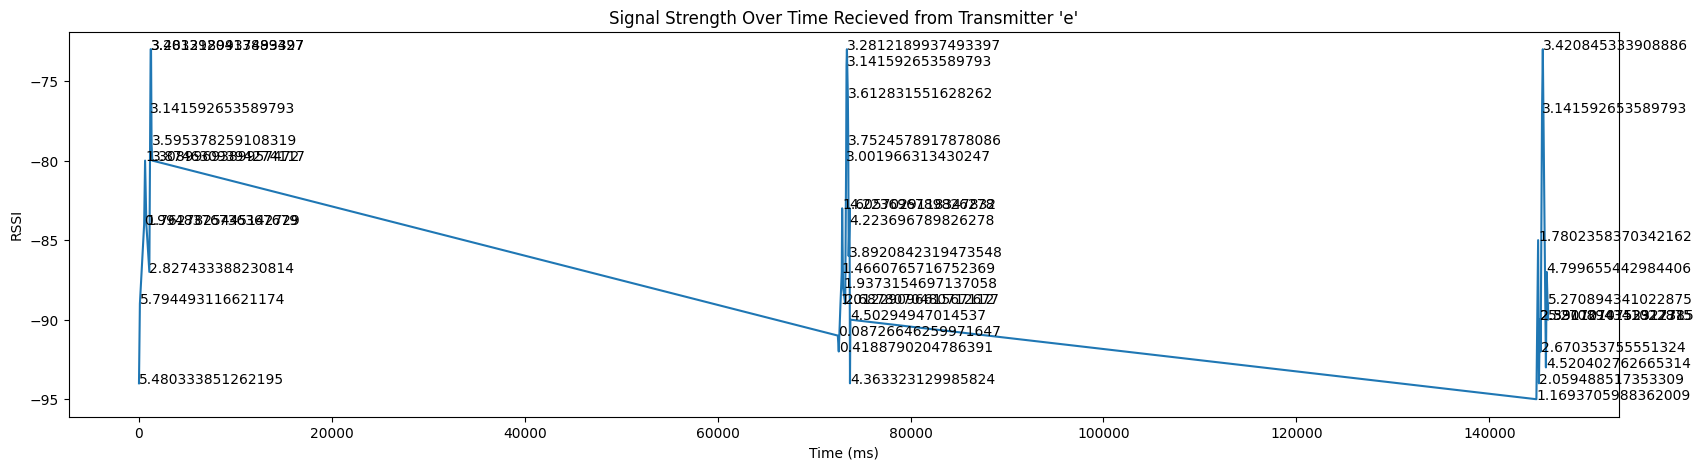

In [145]:
for id, data in enumerate(testdata):
    plt.figure(figsize=[20, 5])
    plt.plot(data[:, 2], data[:, 0])
    for point in data:
        plt.text(point[2],point[0],point[1])
    plt.title("Signal Strength Over Time Recieved from Transmitter '" + transmitters[id][0] + "'")
    plt.ylabel("RSSI")
    plt.xlabel("Time (ms)")

(-100.0, -70.0)

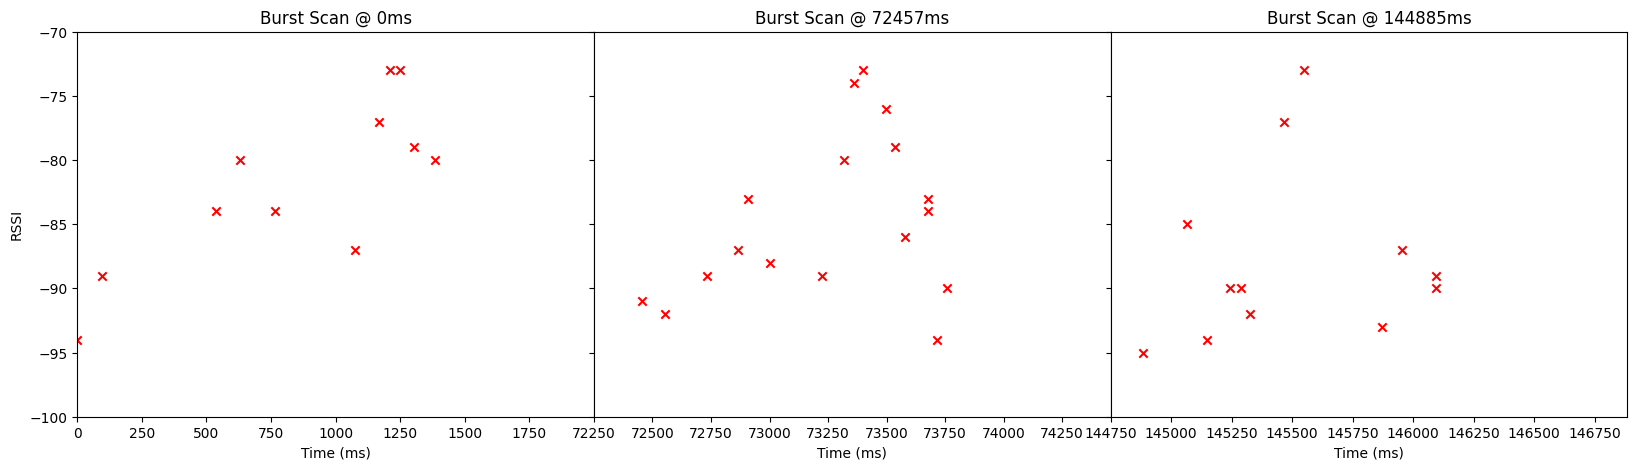

In [161]:
for id, data in enumerate(testdata):
    burststarts = data[[0]+list(np.where(np.diff(data[:,2])>5000)[0]+1), 2]
    fig, axes = plt.subplots(1, len(burststarts), figsize=(20,5), sharey=True)

    for bursti, burstt in enumerate(burststarts):
        ax = axes[bursti]
        ax.scatter(data[:, 2], data[:, 0], marker='x', color='r')
        ax.set_xlim([burstt, burstt + 2000])
        ax.set_title("Burst Scan @ " + str(int(burstt)) + "ms")
        ax.set_xlabel("Time (ms)")
        if bursti == 0:  # Only label the first subplot to avoid repetition
            ax.set_ylabel("RSSI")
        xticks = ax.get_xticks()
        ax.set_xticks(xticks[:-1])  # drop last tick

fig.subplots_adjust(wspace=0.00)
plt.ylim(-100,-70)

In [17]:

plt.scatter(xxLon,yyLat)
plt.text(xxLon[0],yyLat[0],'c')
plt.text(xxLon[1],yyLat[1],'f')
plt.text(xxLon[2],yyLat[2],'b')
plt.text(xxLon[3],yyLat[3],'e')
plt.scatter(xxLon[4],yyLat[4])
plt.text(xxLon[4],yyLat[4],'bee')

cAngle = (6.23)
fAngle = (4.031323129985824 )/1
bAngle = (4.904375198104066)
eAngle = (3.141592653589793 ) / 1

plt.plot([xxLon[0], xxLon[0]+AngleToVector(cAngle)[0]*70],[yyLat[0],yyLat[0]+AngleToVector(cAngle)[1]*70],color='grey',alpha=0.1)
plt.plot([xxLon[1], xxLon[1]+AngleToVector(fAngle)[0]*70],[yyLat[1],yyLat[1]+AngleToVector(fAngle)[1]*70],color='grey',alpha=0.1)
plt.plot([xxLon[2], xxLon[2]+AngleToVector(bAngle)[0]*70],[yyLat[2],yyLat[2]+AngleToVector(bAngle)[1]*70],color='grey',alpha=0.1)
plt.plot([xxLon[3], xxLon[3]+AngleToVector(eAngle)[0]*70],[yyLat[3],yyLat[3]+AngleToVector(eAngle)[1]*70],color='grey',alpha=0.1)

NameError: name 'xxLon' is not defined